# Media, Mediana, Moda, Varianza, Desviación Estándar
- Conceptos basicos Numpy
- Operaciones Basicas
- Ordenamiento y Posicion
- Graficos Basicos
- Analisis de Correlacion / Mapas de Calor
- Graficos Scatterplot

In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../../../Archivos-Analisis/files-tarea-m30/fifa_eda.csv')
df

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
0,158023,L. Messi,31,Argentina,94,94,FC Barcelona,110500.0,565.0,Left,5.0,4.0,RF,2004,2021-01-01,5.583333,159.0,226500.0
1,20801,Cristiano Ronaldo,33,Portugal,94,94,Juventus,77000.0,405.0,Right,5.0,5.0,ST,2018,2022-01-01,6.166667,183.0,127100.0
2,190871,Neymar Jr,26,Brazil,92,93,Paris Saint-Germain,118500.0,290.0,Right,5.0,5.0,LW,2017,2022-01-01,5.750000,150.0,228100.0
3,193080,De Gea,27,Spain,91,93,Manchester United,72000.0,260.0,Right,4.0,1.0,GK,2011,2020-01-01,6.333333,168.0,138600.0
4,192985,K. De Bruyne,27,Belgium,91,92,Manchester City,102000.0,355.0,Right,4.0,4.0,RCM,2015,2023-01-01,5.916667,154.0,196400.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,238813,J. Lundstram,19,England,47,65,Crewe Alexandra,60.0,1.0,Right,1.0,2.0,CM,2017,2019-01-01,5.750000,134.0,143.0
18203,243165,N. Christoffersson,19,Sweden,47,63,Trelleborgs FF,60.0,1.0,Right,1.0,2.0,ST,2018,2020-01-01,6.250000,170.0,113.0
18204,241638,B. Worman,16,England,47,67,Cambridge United,60.0,1.0,Right,1.0,2.0,ST,2017,2021-01-01,5.666667,148.0,165.0
18205,246268,D. Walker-Rice,17,England,47,66,Tranmere Rovers,60.0,1.0,Right,1.0,2.0,RW,2018,2019-01-01,5.833333,154.0,143.0


## Operaciones Basicas

- Vamos a generar informacion estadistica de columnas numericas como: Age, Overall y Potenctial
- El primer paso es tranformarlas en array tipo numpy

In [4]:
# Transformacion de las columnas
age_np = df[['Age']].to_numpy()
height_np = df[['Height']].to_numpy()
weight_np = df[['Weight']].to_numpy()
overall_np = df[['Overall']].to_numpy()
potential_np = df[['Potential']].to_numpy()

In [5]:
# Mostramos el tipo de variable
type(age_np)

numpy.ndarray

In [6]:
age_np[:10,0]

array([31, 33, 26, 27, 27, 27, 32, 31, 32, 25])

In [9]:
# Operacion de condicion
np.where(age_np > 30, age_np, 0)

array([[31],
       [33],
       [ 0],
       ...,
       [ 0],
       [ 0],
       [ 0]], shape=(18207, 1))

In [10]:
# Indica el jugador mas viejo
ixoldest = np.argmax(age_np)
age_np[ixoldest]

array([45])

## Operaciones Estadisticas

In [11]:
# Obten la media de la edad
media = age_np.mean()
format_media = "{:.2f}".format(media)
print(f'La media de la edad de los jugadores es = {format_media} años')

La media de la edad de los jugadores es = 25.12 años


In [ ]:
# Percentiles
for i in range(0, 100, 5):
    print(i, "% : ", np.percentile(age_np, i))

0 % :  16.0
5 % :  18.0
10 % :  19.0
15 % :  20.0
20 % :  21.0
25 % :  21.0
30 % :  22.0
35 % :  23.0
40 % :  23.0
45 % :  24.0
50 % :  25.0
55 % :  25.0
60 % :  26.0
65 % :  27.0
70 % :  28.0
75 % :  28.0
80 % :  29.0
85 % :  30.0
90 % :  32.0
95 % :  33.0


In [13]:
# Moda
vals, counts = np.unique(age_np, return_counts=True)
index = np.argmax(counts) # El indice de la edad mas contada
moda = vals[index] # La edad mas repetida
print(f'La moda de la edad de los jugadores es = {moda:.2f} años')

La moda de la edad de los jugadores es = 21.00 años


In [16]:
# Mediana
mediana = np.median(age_np)
print(f'La mediana de la edad de los jugadores es = {mediana:.2f} años')

La mediana de la edad de los jugadores es = 25.00 años


In [18]:
# Desviacion estandar
desvstd = age_np.std()
print(f'La desviacion estandar de la edad de los jugadores es = {desvstd:.2f} años')

La desviacion estandar de la edad de los jugadores es = 4.67 años


## Graficos Numpy

In [19]:
import matplotlib.pyplot as plt

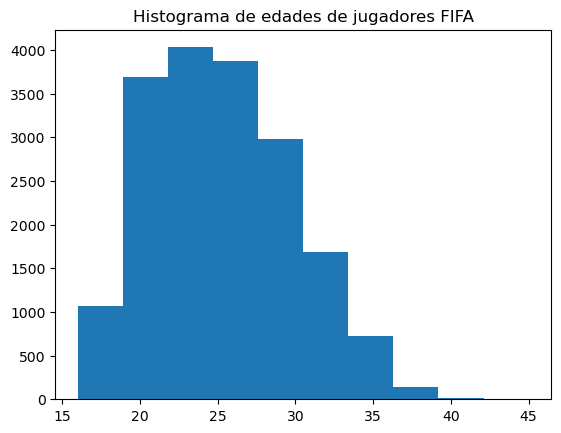

In [20]:
plt.hist(age_np)
plt.title('Histograma de edades de jugadores FIFA')
plt.show()

In [21]:
import seaborn as sns

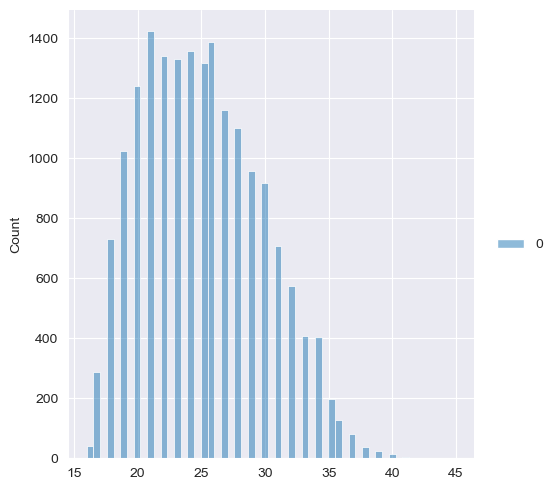

In [22]:
sns.set_style('darkgrid')
sns.displot(age_np)

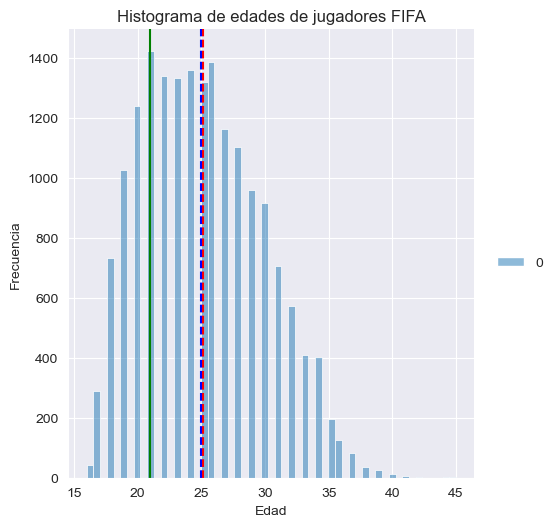

In [23]:
# Se agrega la media, mediana y moda al grafico
sns.set_style('darkgrid')
sns.displot(age_np)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Histograma de edades de jugadores FIFA')
plt.axvline(x=age_np.mean(), color='red', ls='--')
plt.axvline(x=mediana, color='blue', ls='--')
plt.axvline(x=moda, color='green', ls='-')

## Ordenamiento y Posicion

In [24]:
# Se tienen miles de registros
# Se usa para validar el numero total de registros
print('Numero total de jugadores: ', len(age_np))

Numero total de jugadores:  18207


In [25]:
# Maxima edad
print('La edad maxima de los jugadores es: ',np.max(age_np))
print('La edad minima de los jugadores es: ',np.min(age_np))

La edad maxima de los jugadores es:  45
La edad minima de los jugadores es:  16


In [28]:
# Genera un array con las primeras edades
age_top = np.concatenate(age_np)

print('Comparamos el formato de los dos arrays:')
print('//////////////////////')
print(age_np[0:10])
print('//////////////////////')
print(age_top[0:10])

Comparamos el formato de los dos arrays:
//////////////////////
[[31]
 [33]
 [26]
 [27]
 [27]
 [27]
 [32]
 [31]
 [32]
 [25]]
//////////////////////
[31 33 26 27 27 27 32 31 32 25]


In [29]:
# Lo concatena para no tener un array de arrays, sion un numero
age_top_num = np.sort(age_top)
age_top_num

array([16, 16, 16, ..., 44, 44, 45], shape=(18207,))

In [30]:
# Para ordenar en reversa
age_top_num_rev = age_top_num [::-1]
age_top_num_rev

array([45, 44, 44, ..., 16, 16, 16], shape=(18207,))

In [31]:
# top 20
age_top_num_rev [0:20]

array([45, 44, 44, 42, 41, 41, 41, 41, 41, 40, 40, 40, 40, 40, 40, 40, 40,
       40, 40, 40])

In [32]:
# Obtiene del df laos primeros 20 registros de jugadores ordenados por edad
df.sort_values(by=['Age'], ascending=False).head(20)

,ID,Name,Age,Nationality,Overall,Potential,Club,Value,Wage,Preferred Foot,International Reputation,Skill Moves,Position,Joined,Contract Valid Until,Height,Weight,Release Clause
4741,140029,O. Pérez,45,Mexico,71,71,Pachuca,160.0,8.0,Right,2.0,1.0,GK,1991,2021-01-01,5.666667,165.0,272.000000
18183,53748,K. Pilkington,44,England,48,48,Cambridge United,NaN,1.0,Right,1.0,1.0,GK,2018,2023-01-01,6.166667,190.0,4585.060806
17726,51963,T. Warner,44,Trinidad & Tobago,53,53,Accrington Stanley,NaN,1.0,Right,1.0,1.0,GK,2018,2019-01-01,6.333333,185.0,4585.060806
10545,140183,S. Narazaki,42,Japan,65,65,Nagoya Grampus,40.0,1.0,Right,2.0,1.0,GK,1999,2021-01-01,6.166667,176.0,50.000000
7225,142998,C. Muñoz,41,Argentina,68,68,CD Universidad de Concepción,60.0,1.0,Right,1.0,1.0,GK,2013,2018-01-01,5.833333,161.0,84.000000
1120,156092,J. Villar,41,Paraguay,77,77,NaN,NaN,0.0,Right,2.0,1.0,GK,2016,NaN,5.916667,187.0,4585.060806
12192,208927,H. Sulaimani,41,Saudi Arabia,63,63,Ohod Club,NaN,3.0,Left,1.0,3.0,LB,2018,2019-01-01,5.666667,154.0,4585.060806
15426,18745,M. Tyler,41,England,59,59,Peterborough United,10.0,1.0,Right,1.0,1.0,GK,2016,2019-01-01,6.000000,183.0,18.000000
4228,3665,B. Nivet,41,France,71,71,ESTAC Troyes,NaN,5.0,Right,2.0,3.0,CAM,2012,2019-01-01,5.833333,165.0,4585.060806
10356,49511,F. Kippe,40,Norway,65,65,Lillestrøm SK,NaN,1.0,Left,1.0,2.0,LCB,2002,2019-01-01,6.333333,214.0,4585.060806


In [33]:
# Grafico
from matplotlib.ticker import StrMethodFormatter

x = df.sort_values(by=['Age'], ascending=False).head(10)[['Name', 'Age']]
x

,Name,Age
4741,O. Pérez,45
18183,K. Pilkington,44
17726,T. Warner,44
10545,S. Narazaki,42
7225,C. Muñoz,41
1120,J. Villar,41
12192,H. Sulaimani,41
15426,M. Tyler,41
4228,B. Nivet,41
10356,F. Kippe,40


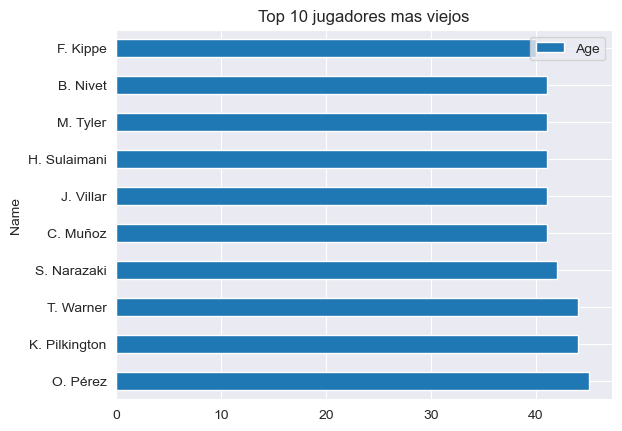

In [34]:
ax = x.plot.barh(y='Age', x='Name', title='Top 10 jugadores mas viejos')

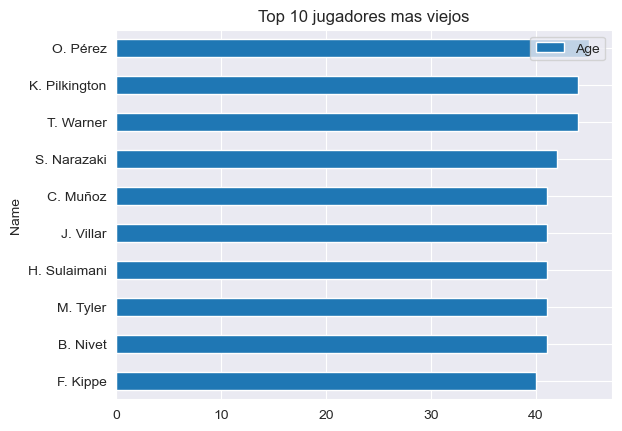

In [ ]:
# Le doy la vuelta al array
ax = x.iloc[::-1].plot.barh(y='Age', x='Name', title='Top 10 jugadores mas viejos')

## Correlacion

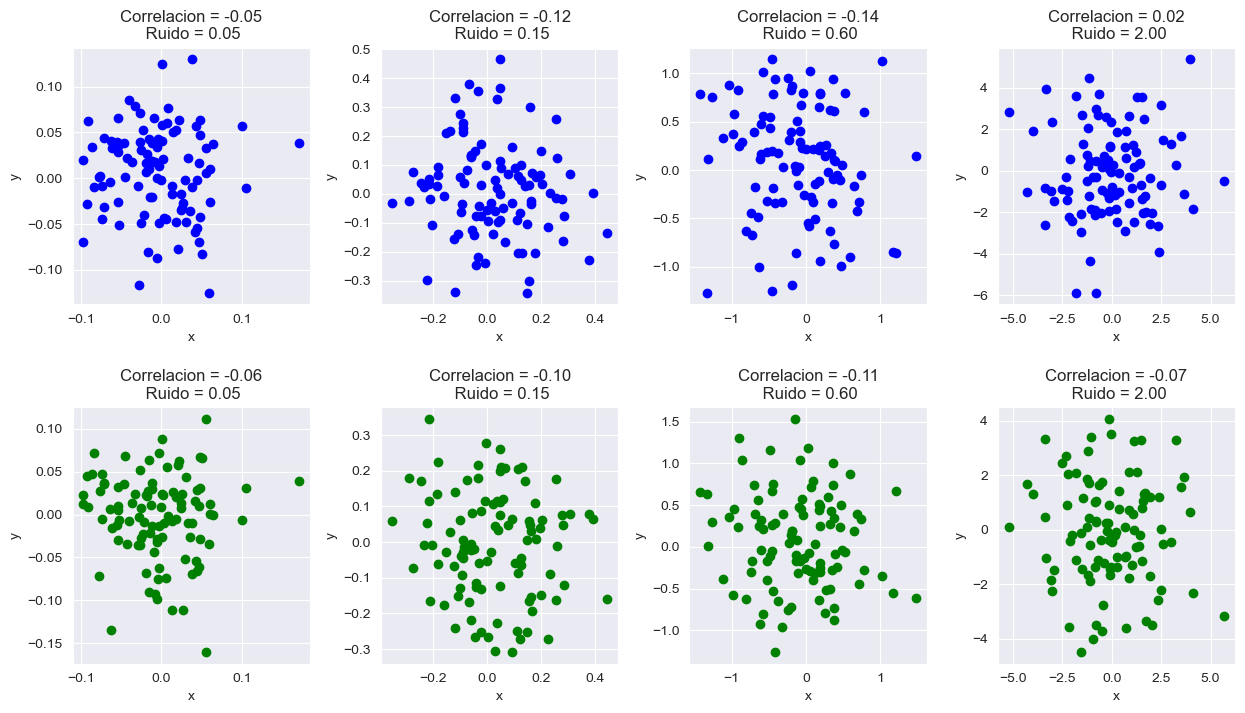

In [39]:
# Grafico de diferentes correlaciones simultaneas
seed = 13
rand = np.random.RandomState(seed)
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(15,8))

x = rand.uniform(0,1,100)
x= np.vstack((x,x*2+1))
x= np.vstack((x,-x[0,]*2+1))
x= np.vstack((x, rand.normal(1,3,100)))

for noise, i in zip([0.05,0.15,0.6,2],[0,1,2,3]):
    # Añade ruido
    x_with_noise = x=rand.normal(0,noise,x.shape)

    # Calcula la correlacion
    rho_noise = np.corrcoef(x_with_noise)

    # Correalacion positiva en la primera linea y negatica en la segunda
    ax[0,i].scatter(x_with_noise[0,], x_with_noise[1,], color='blue')
    ax[1,i].scatter(x_with_noise[0,], x_with_noise[2,], color='green')

    ax[0,i].title.set_text('Correlacion = ' + '{:.2f}'.format(rho_noise[0,1]) + '\n Ruido = ' + '{:.2f}'.format(noise))
    ax[1,i].title.set_text('Correlacion = ' + '{:.2f}'.format(rho_noise[0,2]) + '\n Ruido = ' + '{:.2f}'.format(noise))

    ax[0,i].set(xlabel='x', ylabel='y')
    ax[1,i].set(xlabel='x', ylabel='y')

fig.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

In [ ]:
# Correlacion con df
df.corr(numeric_only=True)

,ID,Age,Overall,Potential,Value,Wage,International Reputation,Skill Moves,Joined,Height,Weight,Release Clause
ID,1.000000,-0.739208,-0.417025,0.047074,-0.139837,-0.204610,-0.356191,-0.056914,0.206749,-0.090090,-0.191193,-0.121297
Age,-0.739208,1.000000,0.452350,-0.253312,0.078315,0.141145,0.253765,0.027649,-0.202658,0.082506,0.229940,0.058672
Overall,-0.417025,0.452350,1.000000,0.660939,0.631848,0.571926,0.499491,0.414463,-0.169281,0.038527,0.154557,0.597821
Potential,0.047074,-0.253312,0.660939,1.000000,0.579608,0.486413,0.372993,0.354290,-0.047661,-0.009791,-0.006935,0.562346
Value,-0.139837,0.078315,0.631848,0.579608,1.000000,0.858086,0.656158,0.317246,-0.115991,0.002827,0.046702,0.973310
Wage,-0.204610,0.141145,0.571926,0.486413,0.858086,1.000000,0.668635,0.263205,-0.142337,0.019638,0.064764,0.828161
International Reputation,-0.356191,0.253765,0.499491,0.372993,0.656158,0.668635,1.000000,0.208153,-0.133009,0.034881,0.088340,0.620863
Skill Moves,-0.056914,0.027649,0.414463,0.354290,0.317246,0.263205,0.208153,1.000000,0.020692,-0.422753,-0.351209,0.297471
Joined,0.206749,-0.202658,-0.169281,-0.047661,-0.115991,-0.142337,-0.133009,0.020692,1.000000,0.001188,-0.028274,-0.115374
Height,-0.090090,0.082506,0.038527,-0.009791,0.002827,0.019638,0.034881,-0.422753,0.001188,1.000000,0.754678,0.001835


In [48]:
# Arrays are already flattened, flatten them properly
age_np = age_np.flatten()
height_np = height_np.flatten()
weight_np = weight_np.flatten()
overall_np = overall_np.flatten()
potential_np = potential_np.flatten()

In [49]:
r = np.corrcoef(weight_np, height_np)
r

array([[1.        , 0.75467822],
       [0.75467822, 1.        ]])

<Axes: >

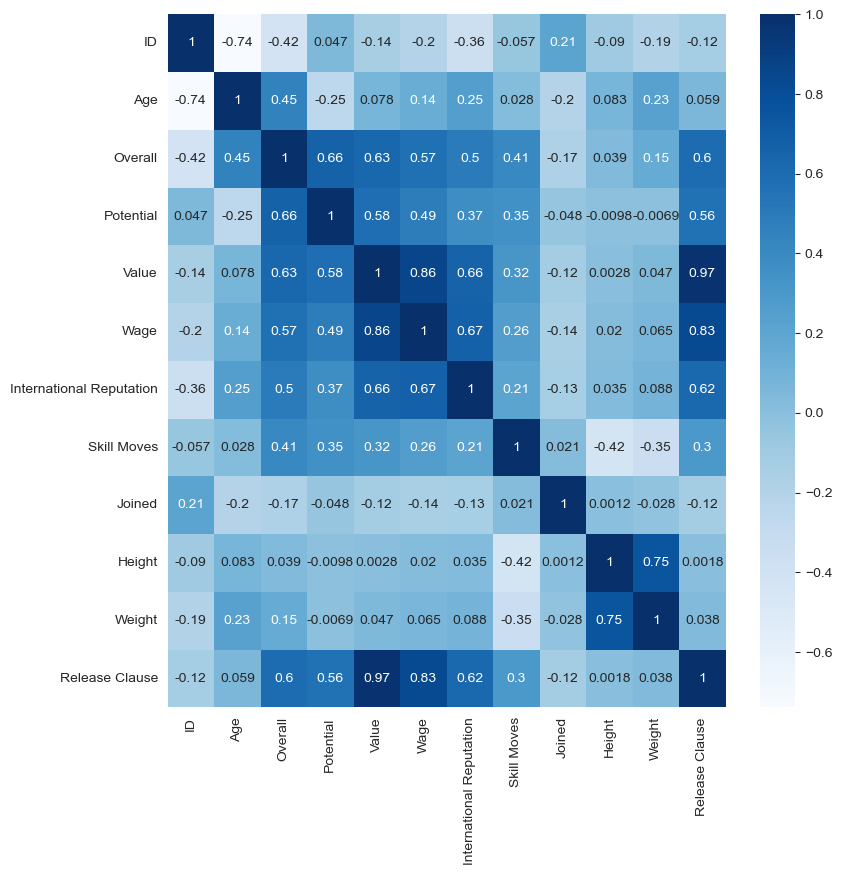

In [50]:
plt.figure(figsize=(9,9))

corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='Blues', annot=True)

Text(0.5, 1.0, 'Triangulo de correlacion entre variables numericas')

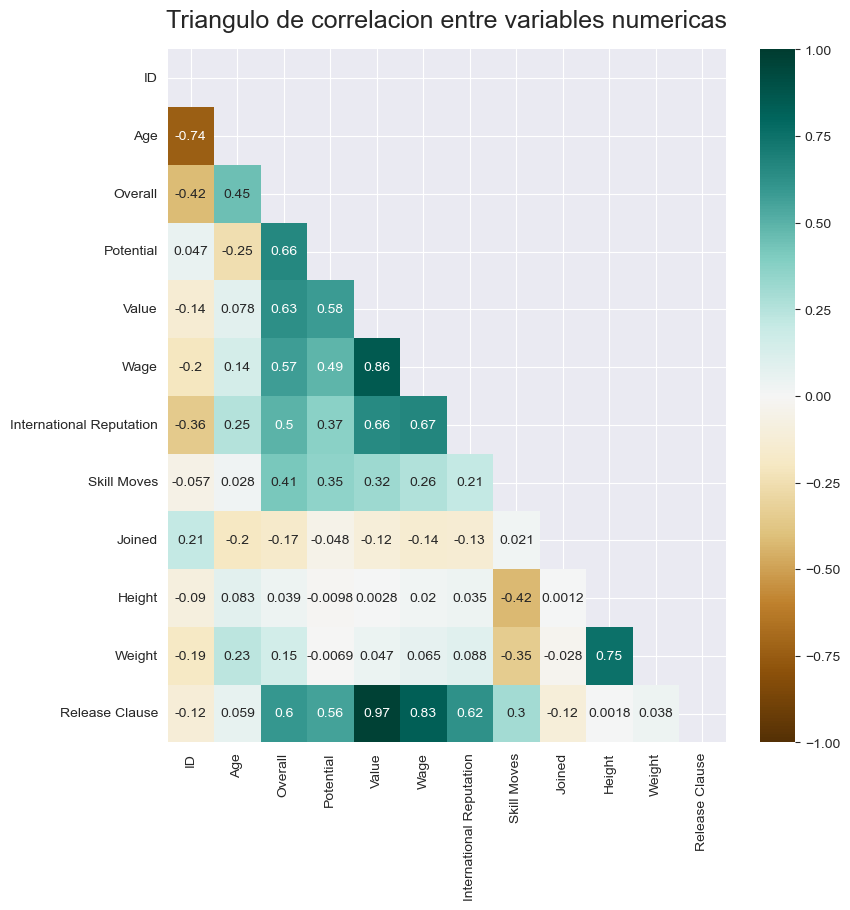

In [52]:
# Grafico de triangulo de correlacion
plt.figure(figsize=(9,9))
mask = np.triu(np.ones_like(corr, dtype=bool))
heatmap = sns.heatmap(corr, mask=mask, vmin=-1, vmax=1, annot=True, cmap='BrBG')
heatmap.set_title('Triangulo de correlacion entre variables numericas', fontdict={'fontsize':18}, pad=16)

## Scatterplots
- Buscar una relacion entre variables

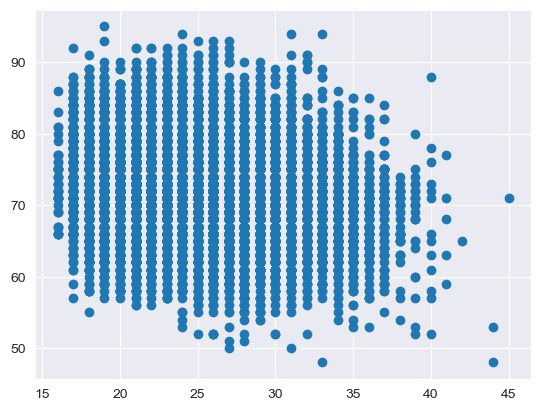

In [53]:
plt.scatter(x=age_np, y=potential_np)

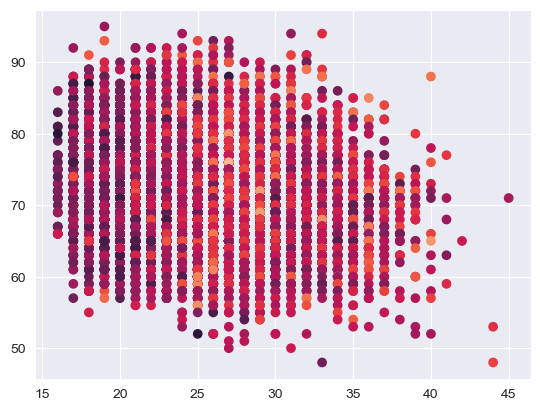

In [54]:
# Grafico buscando la explicacion entre potential y edad, con color = peso
plt.scatter(x=age_np, y=potential_np, c=weight_np)

In [56]:
np.corrcoef(height_np, weight_np)

array([[1.        , 0.75467822],
       [0.75467822, 1.        ]])

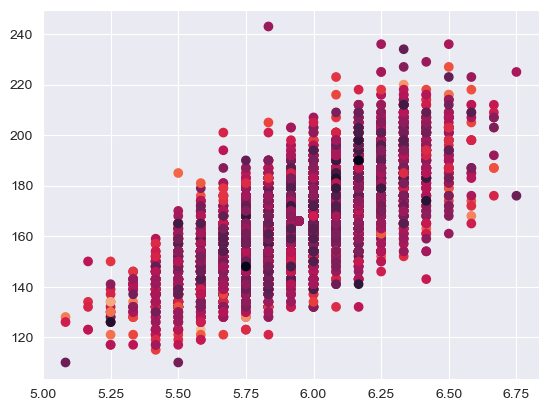

In [55]:
plt.scatter(x=height_np, y=weight_np, c=potential_np)


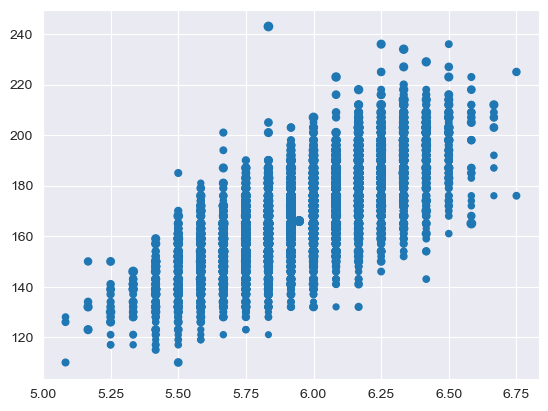

In [58]:
# Grafico buscando la explicacion entre altura y peso, con superficie = edad
plt.scatter(x=height_np, y=weight_np, s=age_np)

In [61]:
np.corrcoef(potential_np, weight_np)


array([[ 1.        , -0.00693528],
       [-0.00693528,  1.        ]])

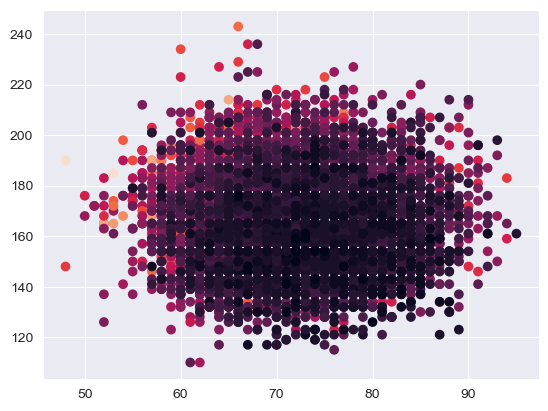

In [60]:
# Grafico buscando la explicacion entre potencial y peso, con color = edad
plt.scatter(x=potential_np, y=weight_np, c=age_np)